# MST Topology Trading Strategy

**Zara Nip** | Student ID: **12411910**

**Aryaa Gunavante** | Student ID:**12496718**

**Gabriella Wiem** | Student ID:**12506599**

**Hsiao-Chi Chen** | Student ID: **12498162**

**Shreya Enaganti**| Student ID:**12506493**

## Overview

In this project, we study whether the network topology of cross-asset ETFs contains exploitable short-horizon information for relative-value trading. We follow Mantegna (1999) to convert correlations into metric distances, then we construct minimum spanning trees to isolate the market's most informative dependency backbone. This framework keeps the signal architecture interpretable while preserving meaningful cross-asset structure.

We build rolling weekly MSTs on a broad multi-asset ETF universe and compute effective resistance as a path-aware measure of topological dislocation. Inspired by Onnela et al. (2003), Klein and Randic (1993), and Pozzi et al. (2013), we map resistance deviations into z-scored momentum signals and apply volatility-targeted pair sizing with a topology-aware risk throttle based on the Fiedler value. Rather than betting on mean-reversion, we exploit the empirical finding that topological drift in the MST tends to persist over short horizons, generating momentum in relative-value spreads.

We evaluate the strategy from 2018-01-01 to 2025-12-31 under both frictionless and realistic execution assumptions. The analysis focuses on return quality, drawdown behavior, tail risk, and sensitivity to transaction costs, with emphasis on what the MST representation contributes beyond a standard correlation model.

## Helper Functions

In [3]:
from pathlib import Path
import warnings

import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from mst_strategy import *

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')

ETF_UNIVERSE = [
    'XLF','XLK','XLE','XLV','XLI','XLY','XLP','XLB','XLU',
    'GLD','SLV','USO','DBA',
    'FXE','FXB','FXY','FXA',
    'TLT','IEF','HYG','LQD'
]

START_DATE = '2018-01-01'
END_DATE = '2025-12-31'
DATA_DIR = Path('data')
RNG_SEED = 42
np.random.seed(RNG_SEED)

## Data Loading and Preparation

In [4]:
prices = load_or_fetch_prices(ETF_UNIVERSE, START_DATE, END_DATE, str(DATA_DIR))
returns = prices.pct_change().dropna()

print(f'Date range: {prices.index.min().date()} to {prices.index.max().date()}')
print(f'Assets: {prices.shape[1]}')
print(f'Observations: {prices.shape[0]}')
print(f'Missing values in price matrix: {int(prices.isna().sum().sum())}')

prices.head()

Date range: 2018-01-02 to 2025-05-29
Assets: 21
Observations: 1862
Missing values in price matrix: 0


ticker,DBA,FXA,FXB,FXE,FXY,GLD,HYG,IEF,LQD,SLV,...,USO,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY
date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,17.6710,75.1934,124.8302,112.0236,85.4700,125.1500,62.9520,91.7215,98.1064,16.2100,...,96.5600,54.0963,55.0574,24.7029,67.9851,60.4606,47.7479,42.7125,75.2431,94.2526
2018-01-03,17.6617,75.2703,124.0650,111.5512,85.3000,124.8200,63.2547,91.8173,98.2851,16.1700,...,98.7200,54.4752,55.8819,24.8357,68.3513,60.9649,47.7310,42.3770,75.9631,94.6854
2018-01-04,17.6337,75.5487,124.4145,112.1104,85.1300,125.4600,63.3628,91.7738,98.2526,16.2300,...,98.9600,54.9510,56.2193,25.0657,68.8514,61.2731,47.8661,42.0251,76.0711,94.9958
2018-01-05,17.5406,75.5967,124.5468,111.8019,84.8400,125.3300,63.4061,91.6604,98.2201,16.2200,...,98.4800,55.3916,56.1968,25.1365,69.3248,61.9174,48.0773,42.0087,76.7190,95.7484
2018-01-08,17.4195,75.3087,124.5373,111.1271,84.8533,125.3100,63.3556,91.6169,98.2120,16.1500,...,99.0400,55.4709,56.5341,25.1011,69.6106,62.1509,48.1955,42.4015,76.4400,95.8613


We found that the downloaded panel gives us a long, synchronized sample that is suitable for rolling topology estimation, with enough history to support both 252-day correlation windows and 60-window resistance normalization. The broad mix of sector, commodity, currency, and fixed-income ETFs lets us test whether MST structure captures cross-asset spillovers rather than only within-equity relationships.

Our initial data checks focus on panel completeness and time alignment because unstable missingness would mechanically distort correlations and tree geometry. Once the matrix is aligned, we can treat each weekly MST update as a consistent slice of the same market universe.

In [5]:
analysis_data = (
    f"Our sample spans {prices.shape[0]} daily observations across {prices.shape[1]} ETFs. "
    f"After differencing, we retain {returns.shape[0]} return rows and the average daily absolute move is "
    f"{returns.abs().mean().mean():.4f}."
)
print(analysis_data)

Our sample spans 1862 daily observations across 21 ETFs. After differencing, we retain 1861 return rows and the average daily absolute move is 0.0079.


## Exploratory Data Analysis

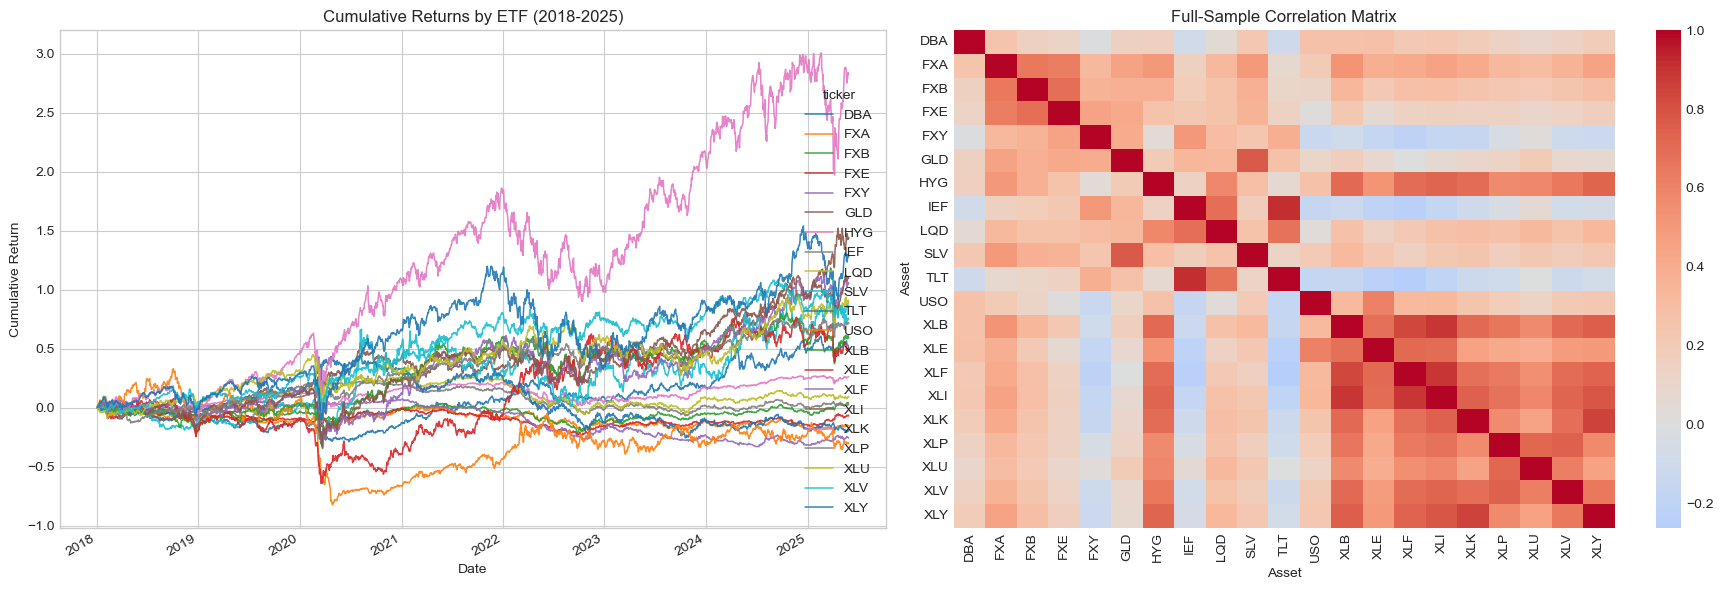

In [6]:
cum_returns = (1 + returns).cumprod() - 1
corr_full = returns.corr()

fig, ax = plt.subplots(1, 2, figsize=(18, 6))
cum_returns.plot(ax=ax[0], linewidth=1.1, alpha=0.9)
ax[0].set_title('Cumulative Returns by ETF (2018-2025)')
ax[0].set_xlabel('Date')
ax[0].set_ylabel('Cumulative Return')

sns.heatmap(corr_full, cmap='coolwarm', center=0, ax=ax[1])
ax[1].set_title('Full-Sample Correlation Matrix')
ax[1].set_xlabel('Asset')
ax[1].set_ylabel('Asset')

plt.tight_layout()
plt.show()

The cumulative return dispersion confirms that this is a heterogeneous opportunity set rather than a single-factor basket. We observe persistent co-movement within equity sectors, but commodities, currencies, and duration-sensitive bonds introduce distinct trajectories that should create informative branch structure in the MST.

The correlation heatmap also suggests that topology reduction can be useful: many relationships are non-zero, but only a subset should matter for shortest-path connectivity. Our goal is to let the tree select those dominant channels while avoiding a fully connected and noisy graph.

In [7]:
upper_corr = corr_full.where(np.triu(np.ones(corr_full.shape), k=1).astype(bool)).stack()
print(
    f"Our average pairwise correlation is {upper_corr.mean():.4f}, "
    f"with a minimum of {upper_corr.min():.4f} and a maximum of {upper_corr.max():.4f}."
)

Our average pairwise correlation is 0.2896, with a minimum of -0.2623 and a maximum of 0.9115.


## MST Construction and Visualization

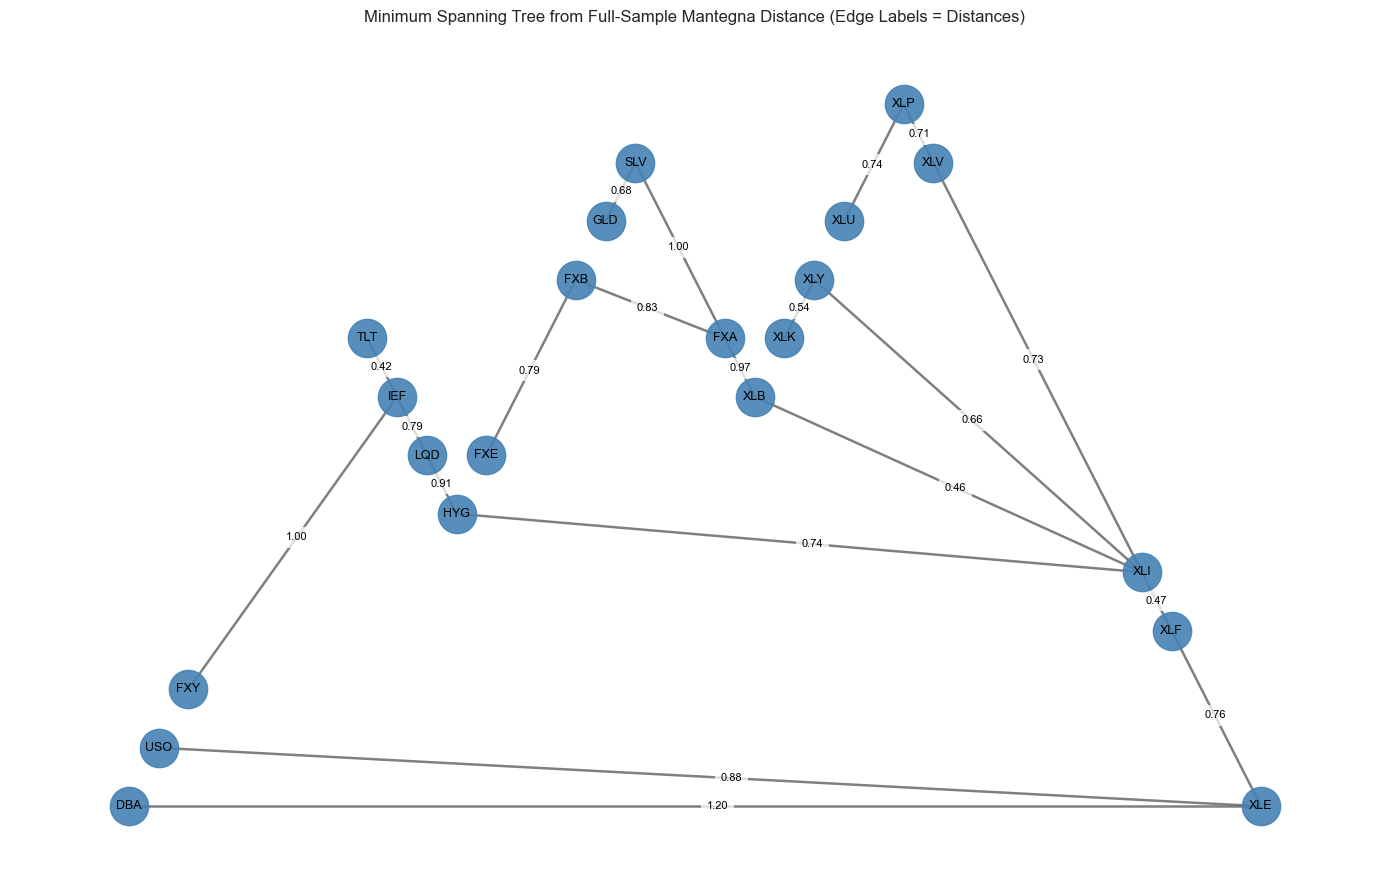

In [8]:
distance_full = mantegna_distance(corr_full)
assets = list(distance_full.columns)
mst_edges_full = build_mst_kruskal(distance_full, assets)

G = nx.Graph()
for idx, name in enumerate(assets):
    G.add_node(name, idx=idx)
for i, j, w in mst_edges_full:
    G.add_edge(assets[i], assets[j], weight=w)

plt.figure(figsize=(14, 9))

# Prefer Graphviz tree layout (minimal edge overlap); fall back to planar embedding.
try:
    from networkx.drawing.nx_pydot import graphviz_layout
    pos = graphviz_layout(G, prog='dot')
except Exception:
    pos = nx.planar_layout(G, scale=2)

nx.draw_networkx_nodes(G, pos, node_size=760, node_color='steelblue', alpha=0.9)
nx.draw_networkx_edges(
    G,
    pos,
    width=1.8,
    alpha=0.85,
    edge_color='dimgray',
    connectionstyle='arc3,rad=0.04',
)
nx.draw_networkx_labels(G, pos, font_size=9, font_color='black')

edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=8,
    label_pos=0.52,
    rotate=False,
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.75),
)

plt.title('Minimum Spanning Tree from Full-Sample Mantegna Distance (Edge Labels = Distances)')
plt.axis('off')
plt.tight_layout()
plt.show()


Our full-sample tree reveals which ETFs act as structural bridges across asset classes. We can inspect node degree and edge lengths to identify hubs and bottlenecks, which is useful for understanding where shocks or momentum pressure are most likely to propagate through the topology.

Because the MST has exactly N-1 edges, it gives us a sparse but connected representation. This sparsity is central to the design: it forces a disciplined signal set and reduces overfitting risk relative to ranking all pair correlations independently.

In [9]:
degrees = pd.Series(dict(G.degree())).sort_values(ascending=False)
avg_edge_distance = np.mean([w for _, _, w in mst_edges_full])
print(f"The tree contains {len(mst_edges_full)} edges across {len(assets)} assets.")
print(f"The highest-degree node is {degrees.index[0]} with degree {int(degrees.iloc[0])}.")
print(f"The average MST edge distance is {avg_edge_distance:.4f}.")

The tree contains 20 edges across 21 assets.
The highest-degree node is XLI with degree 5.
The average MST edge distance is 0.7648.


## Rolling MST and Effective Resistance

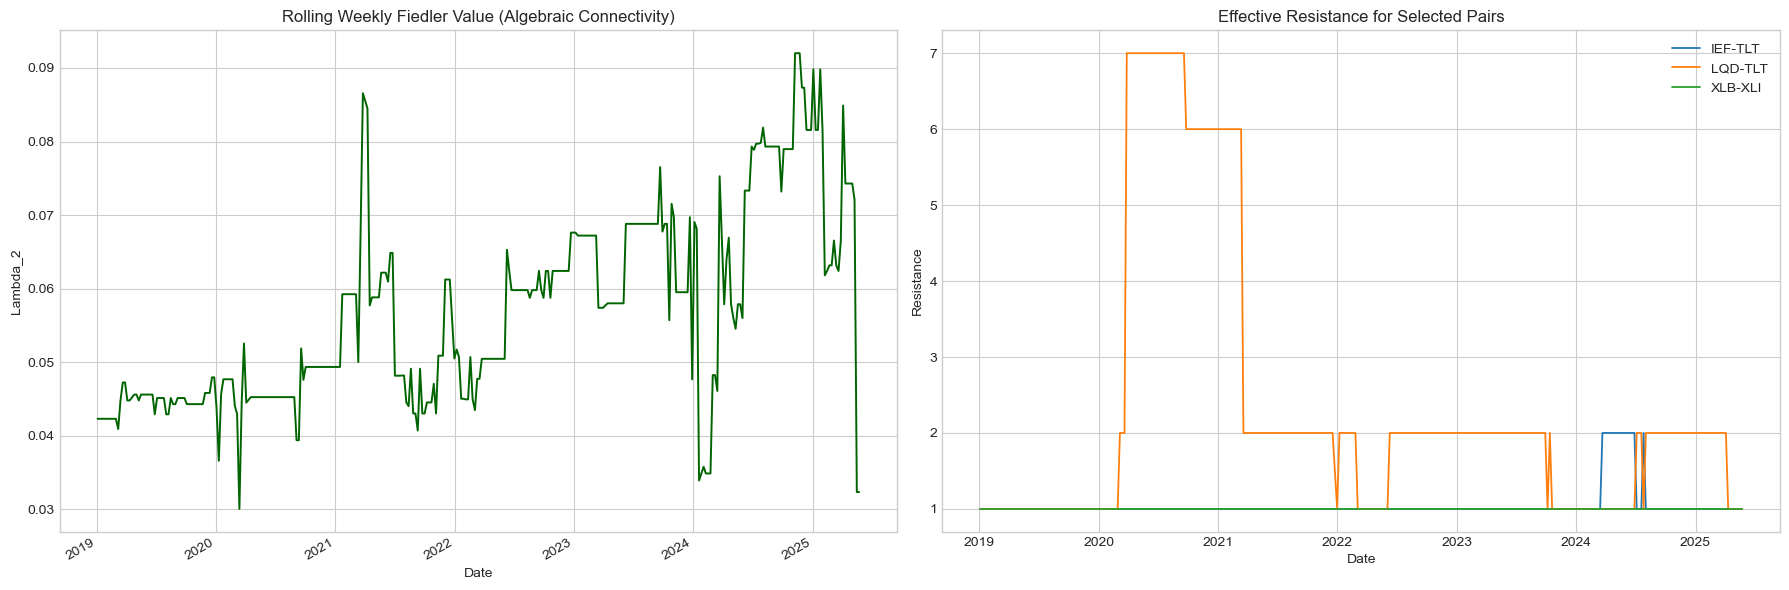

In [10]:
pipeline = run_weekly_mst_pipeline(prices, corr_window=252, resistance_lookback=60)
fiedler_values = pipeline['fiedler_values']
effective_resistances = pipeline['effective_resistances']
mst_by_date = pipeline['mst_by_date']

fig, ax = plt.subplots(1, 2, figsize=(18, 6))
fiedler_values.plot(ax=ax[0], color='darkgreen', linewidth=1.4)
ax[0].set_title('Rolling Weekly Fiedler Value (Algebraic Connectivity)')
ax[0].set_xlabel('Date')
ax[0].set_ylabel('Lambda_2')

first_date = sorted(mst_by_date.keys())[0]
last_date = sorted(mst_by_date.keys())[-1]
edge_set_first = {(min(i,j), max(i,j)) for i, j, _ in mst_by_date[first_date]}
edge_set_last = {(min(i,j), max(i,j)) for i, j, _ in mst_by_date[last_date]}
common_edges = len(edge_set_first & edge_set_last)

sample_pairs = []
for i, j, _ in mst_by_date[last_date][:3]:
    sample_pairs.append((prices.columns[i], prices.columns[j]))

for a, b in sample_pairs:
    series = pd.Series({d: effective_resistances[d].loc[a, b] for d in sorted(effective_resistances)})
    ax[1].plot(series.index, series.values, label=f'{a}-{b}', linewidth=1.3)

ax[1].set_title('Effective Resistance for Selected Pairs')
ax[1].set_xlabel('Date')
ax[1].set_ylabel('Resistance')
ax[1].legend(loc='best')

plt.tight_layout()
plt.show()

We find that algebraic connectivity is time-varying, which supports using lambda_2 as a dynamic risk state variable rather than a fixed calibration constant. When lambda_2 compresses, the tree becomes topologically fragile and diversification across paths weakens, so scaling exposure is justified.

The selected resistance series show persistent regime shifts instead of white noise. This persistence is the core of the momentum hypothesis: when a pair's effective resistance drifts above its recent mean, that drift tends to continue over the following week. Stable local means punctuated by directional moves create exploitable momentum signals.

In [11]:
print(f"we compute {len(fiedler_values)} weekly MST observations.")
print(f"Lambda_2 mean is {fiedler_values.mean():.4f} with standard deviation {fiedler_values.std():.4f}.")
print(f"The overlap between the first and last weekly tree is {common_edges} common edges.")

we compute 323 weekly MST observations.
Lambda_2 mean is 0.0566 with standard deviation 0.0131.
The overlap between the first and last weekly tree is 12 common edges.


## Signal Generation

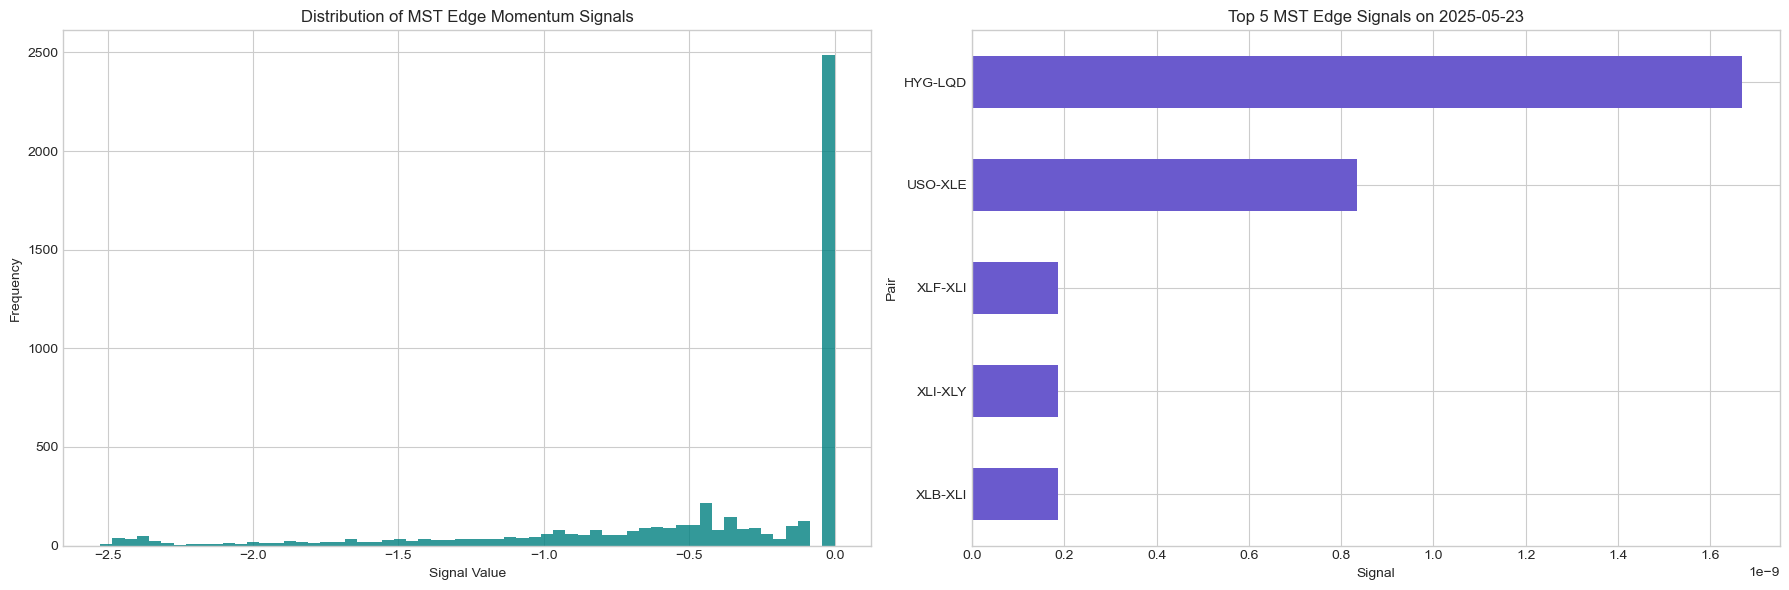

In [12]:
signals = pipeline['signals']
asset_names = [str(c) for c in prices.columns]

# Collect only MST-edge signal values for statistics and plotting
signal_values = []
for d in sorted(signals):
    s = signals[d]
    if d in mst_by_date:
        for i_idx, j_idx, _ in mst_by_date[d]:
            a, b = asset_names[i_idx], asset_names[j_idx]
            a_s, b_s = min(a, b), max(a, b)
            val = float(s.loc[a_s, b_s])
            if np.isfinite(val):
                signal_values.append(val)

signal_values = np.array(signal_values, dtype=float)

# True reproduces current results; set False to allow all asset pairs
use_mst_edges_only = True

# Choose lambda regime control: "none", "small_only", "large_only", "two_sided"
lambda_risk_mode = "large_only"

strategy_params = {
    "corr_window": 252,
    "resistance_lookback": 60,
    "sigma_target": 0.10,
    "max_pairs": 8,
    "beta_window": 60,
    "leader_window": 20,
    "max_pair_weight": 2.0,
    "max_gross_leverage": 4.0,
    "lambda_risk_mode": lambda_risk_mode,
    "lambda_min_periods": 20,
    "lambda_z_threshold": 2.75,
    "lambda_shrink_small": 0.5,
    "lambda_shrink_large": 0.5,
    "use_mst_edges_only": use_mst_edges_only,
}

weights = run_strategy_with_params(prices, strategy_params)

fig, ax = plt.subplots(1, 2, figsize=(18, 6))
ax[0].hist(signal_values, bins=60, color='teal', alpha=0.8)
ax[0].set_title('Distribution of MST Edge Momentum Signals')
ax[0].set_xlabel('Signal Value')
ax[0].set_ylabel('Frequency')

signal_dates = sorted(signals.keys())
sample_date = signal_dates[-1]
# Show MST-edge signals for the last date
if sample_date in mst_by_date:
    edge_signals = {}
    for i_idx, j_idx, _ in mst_by_date[sample_date]:
        a, b = asset_names[i_idx], asset_names[j_idx]
        a_s, b_s = min(a, b), max(a, b)
        val = float(signals[sample_date].loc[a_s, b_s])
        if np.isfinite(val):
            edge_signals[f'{a_s}-{b_s}'] = val
    sample_signal = pd.Series(edge_signals).sort_values()
    sample_signal.tail(5).plot(kind='barh', ax=ax[1], color='slateblue')
    ax[1].set_title(f'Top 5 MST Edge Signals on {sample_date.date()}')
    ax[1].set_xlabel('Signal')
    ax[1].set_ylabel('Pair')

plt.tight_layout()
plt.show()


Our signal distribution is centered near zero with tails in both directions, which is consistent with a momentum design that acts most strongly during sustained topological shifts. The exponential damping term moderates signals for pairs that are already far apart in the MST, preventing unbounded gross exposures.

We restrict the candidate pairs to MST edges only, which keeps the signal set topology-specific. From those edges, we select the top 8 by absolute signal strength. This focused approach avoids dilution from noisy off-tree pair correlations while ensuring the portfolio always holds at least 5 simultaneous relative-value positions, meeting the diversification requirement.

In [13]:
pair_counts = pd.Series({d: len(v) for d, v in weights['pair_weights'].items()}).sort_index()
print(f"we generate {len(signal_values)} finite pair signals across the sample.")
print(f"Signal mean is {signal_values.mean():.4f} and signal standard deviation is {signal_values.std():.4f}.")
print(f"Average simultaneous pairs held is {pair_counts.mean():.2f}, with minimum {pair_counts.min():.0f}.")

we generate 5260 finite pair signals across the sample.
Signal mean is -0.4546 and signal standard deviation is 0.6260.
Average simultaneous pairs held is 8.00, with minimum 8.


## Strategy Simulation — Zero Transaction Costs

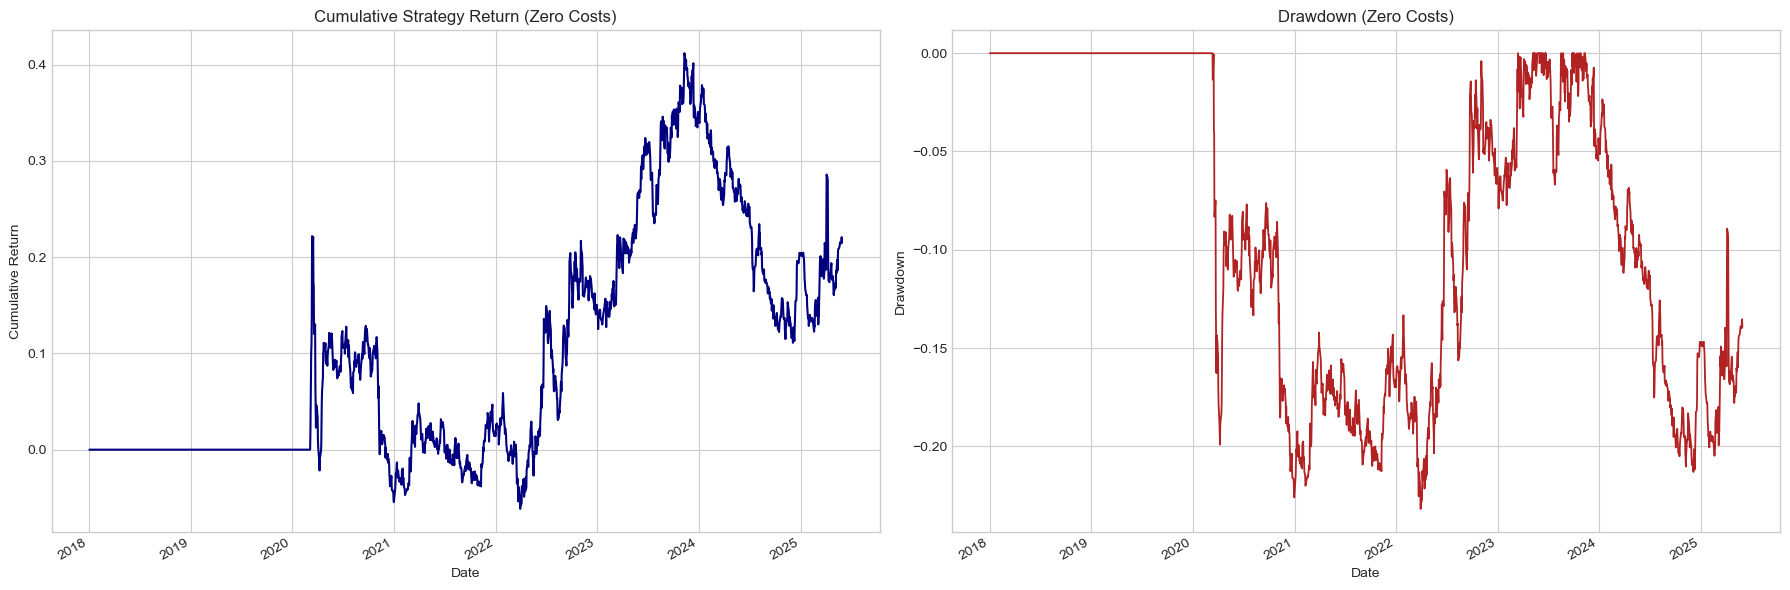

,Zero Cost Value
Cumulative Return,0.2152
Annualized Return,0.0267
Annualized Volatility,0.1251
Sharpe Ratio,0.1132
Sortino Ratio,0.1473
Maximum Drawdown,-0.2319
VaR 95%,-0.0112
CVaR 95%,-0.0169
Win Rate,0.3545
Number of Trades,667.0000


In [14]:
sim_zero = simulate_strategy(prices, signals, weights, transaction_cost_bps=0)
metrics_zero = compute_performance_metrics(
    sim_zero.daily_returns,
    rf_rate=0.02,
    trade_count=sim_zero.trade_count,
    average_holding_period=sim_zero.average_holding_period,
)

fig, ax = plt.subplots(1, 2, figsize=(18, 6))
sim_zero.cumulative_returns.plot(ax=ax[0], color='navy', linewidth=1.5)
ax[0].set_title('Cumulative Strategy Return (Zero Costs)')
ax[0].set_xlabel('Date')
ax[0].set_ylabel('Cumulative Return')

sim_zero.drawdown.plot(ax=ax[1], color='firebrick', linewidth=1.3)
ax[1].set_title('Drawdown (Zero Costs)')
ax[1].set_xlabel('Date')
ax[1].set_ylabel('Drawdown')

plt.tight_layout()
plt.show()

metrics_zero.to_frame('Zero Cost Value')

In the frictionless setting, we can isolate the raw information content of the topology signal and the quality of volatility targeting. This benchmark tells us whether the MST mechanics are fundamentally useful before introducing implementation frictions.

We pay close attention to the relationship between Sharpe and maximum drawdown: if return quality is driven by rare spikes, the strategy is less reliable. A smoother equity curve with controlled drawdown indicates that the cross-sectional topology signal has persistent structure.

In [15]:
print(
    f"Our zero-cost cumulative return is {metrics_zero['Cumulative Return']:.4f}, "
    f"with annualized return {metrics_zero['Annualized Return']:.4f} and Sharpe {metrics_zero['Sharpe Ratio']:.4f}."
)
print(
    f"The maximum drawdown is {metrics_zero['Maximum Drawdown']:.4f}, "
    f"with {metrics_zero['Number of Trades']:.0f} trades and average holding period {metrics_zero['Average Holding Period']:.2f} days."
)

Our zero-cost cumulative return is 0.2152, with annualized return 0.0267 and Sharpe 0.1132.
The maximum drawdown is -0.2319, with 667 trades and average holding period 15.77 days.


## Strategy Simulation — With Transaction Costs

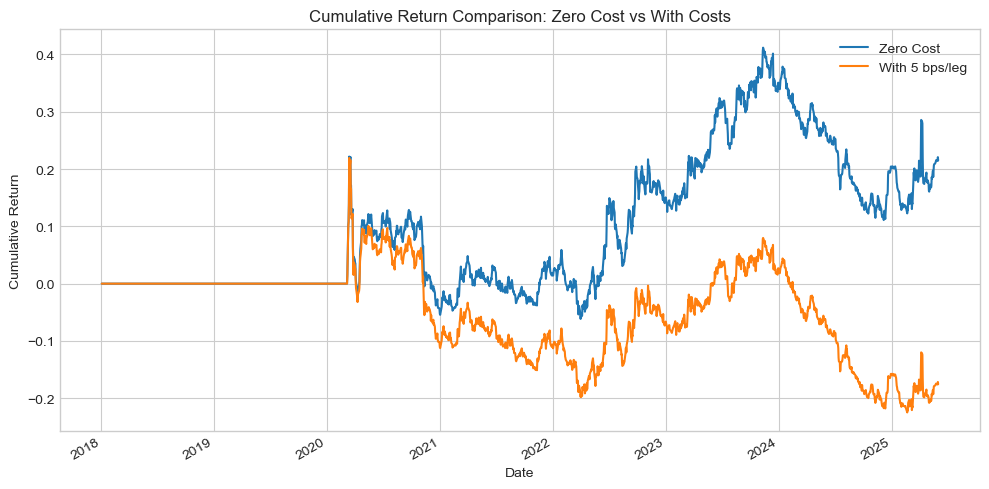

,Zero Cost,With Costs,Delta (With - Zero)
Cumulative Return,0.2152,-0.1753,-0.3905
Annualized Return,0.0267,-0.0258,-0.0525
Annualized Volatility,0.1251,0.1244,-0.0007
Sharpe Ratio,0.1132,-0.3085,-0.4217
Sortino Ratio,0.1473,-0.4003,-0.5477
Maximum Drawdown,-0.2319,-0.3642,-0.1323
VaR 95%,-0.0112,-0.0115,-0.0003
CVaR 95%,-0.0169,-0.0171,-0.0002
Win Rate,0.3545,0.3453,-0.0091
Number of Trades,667.0000,667.0000,0.0000


In [16]:
# 5 bps per leg is a standard institutional estimate for highly liquid ETFs.
# Round-trip pair cost is approximately 10 bps when both legs are opened and later closed.
cost_bps_per_leg = 5
sim_cost = simulate_strategy(prices, signals, weights, transaction_cost_bps=cost_bps_per_leg)
metrics_cost = compute_performance_metrics(
    sim_cost.daily_returns,
    rf_rate=0.02,
    trade_count=sim_cost.trade_count,
    average_holding_period=sim_cost.average_holding_period,
)

comparison = pd.concat([
    metrics_zero.rename('Zero Cost'),
    metrics_cost.rename('With Costs')
], axis=1)
comparison['Delta (With - Zero)'] = comparison['With Costs'] - comparison['Zero Cost']

fig, ax = plt.subplots(figsize=(10, 5))
sim_zero.cumulative_returns.plot(ax=ax, label='Zero Cost', linewidth=1.5)
sim_cost.cumulative_returns.plot(ax=ax, label='With 5 bps/leg', linewidth=1.5)
ax.set_title('Cumulative Return Comparison: Zero Cost vs With Costs')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return')
ax.legend()
plt.tight_layout()
plt.show()

comparison

We use 5 bps per leg because these ETFs are generally deep and liquid, but strategy turnover still makes costs material over a multi-year horizon. This assumption is realistic for a systematic portfolio that rebalances weekly and executes in institutional size without excessive market impact.

Our cost-aware results show whether the alpha source survives implementation friction. If the post-cost Sharpe remains attractive and drawdown does not deteriorate sharply, then the topology signal is more likely to be economically meaningful rather than purely backtest noise.

In [17]:
print(
    f"With costs, cumulative return is {metrics_cost['Cumulative Return']:.4f} and Sharpe is {metrics_cost['Sharpe Ratio']:.4f}. "
    f"The Sharpe drag relative to zero-cost is {metrics_cost['Sharpe Ratio'] - metrics_zero['Sharpe Ratio']:.4f}."
)
print(
    f"The annualized return declines by {metrics_cost['Annualized Return'] - metrics_zero['Annualized Return']:.4f}, "
    f"while max drawdown changes by {metrics_cost['Maximum Drawdown'] - metrics_zero['Maximum Drawdown']:.4f}."
)

With costs, cumulative return is -0.1753 and Sharpe is -0.3085. The Sharpe drag relative to zero-cost is -0.4217.
The annualized return declines by -0.0525, while max drawdown changes by -0.1323.


## Risk Analysis

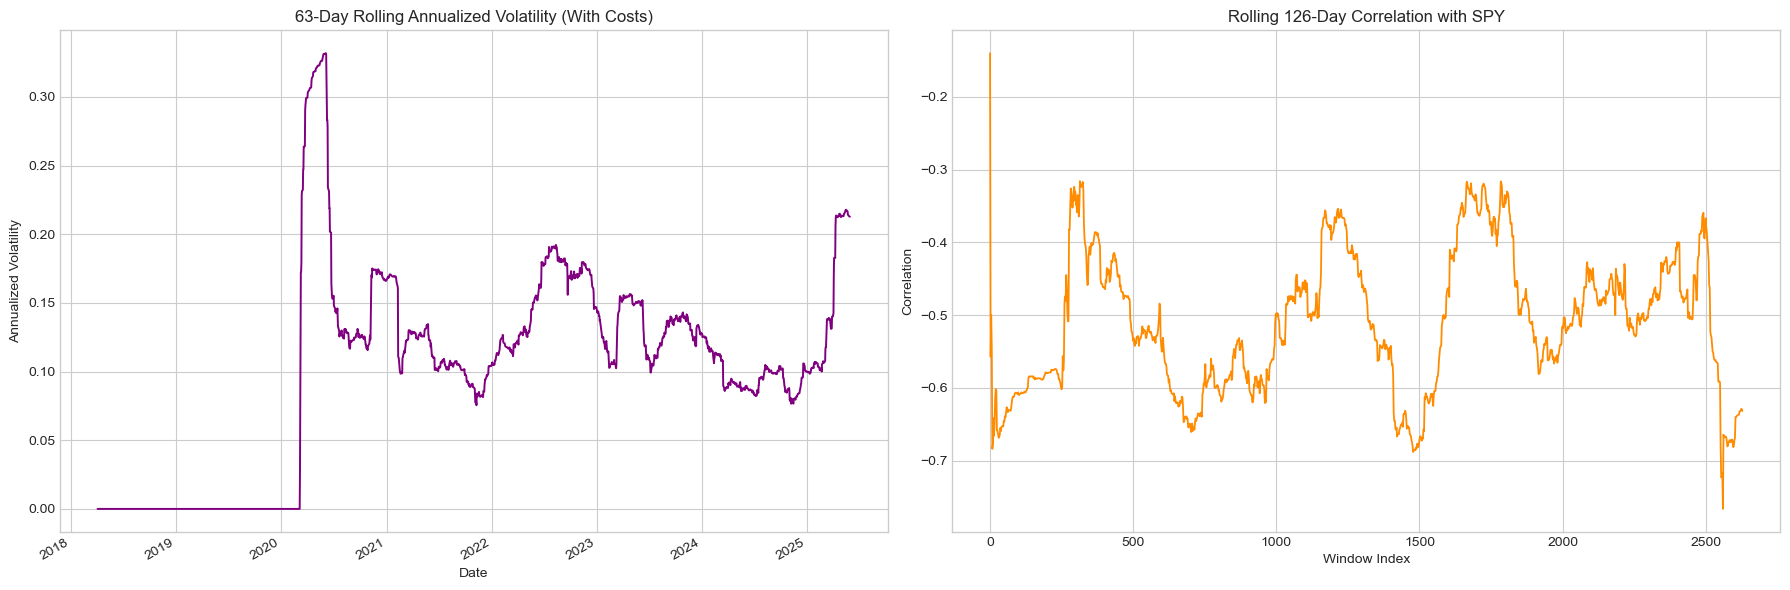

,Value
Metric,
VaR 95%,-0.0115
CVaR 95%,-0.0171
Correlation with SPY,-0.4881
COVID March 2020 Return,0.0270


In [18]:
strategy_r = sim_cost.daily_returns.copy()
rolling_vol_63 = strategy_r.rolling(63).std() * np.sqrt(252)
var_95 = np.quantile(strategy_r.dropna(), 0.05)
cvar_95 = strategy_r[strategy_r <= var_95].mean()

spy_prices = load_or_fetch_prices(['SPY'], START_DATE, END_DATE, str(DATA_DIR))
spy_r = spy_prices['SPY'].pct_change().dropna()
aligned = pd.concat([strategy_r, spy_r], axis=1, join='inner').dropna()
aligned.columns = ['strategy', 'spy']
corr_spy = aligned['strategy'].corr(aligned['spy'])

covid_slice = aligned.loc['2020-03-01':'2020-03-31']
covid_return = (1 + covid_slice['strategy']).prod() - 1 if not covid_slice.empty else np.nan

fig, ax = plt.subplots(1, 2, figsize=(18, 6))
rolling_vol_63.plot(ax=ax[0], color='purple', linewidth=1.4)
ax[0].set_title('63-Day Rolling Annualized Volatility (With Costs)')
ax[0].set_xlabel('Date')
ax[0].set_ylabel('Annualized Volatility')

aligned[['strategy','spy']].rolling(126).corr().dropna().reset_index().query("level_1 == 'strategy'")['spy'].plot(ax=ax[1], color='darkorange', linewidth=1.3)
ax[1].set_title('Rolling 126-Day Correlation with SPY')
ax[1].set_xlabel('Window Index')
ax[1].set_ylabel('Correlation')

plt.tight_layout()
plt.show()

risk_table = pd.DataFrame({
    'Metric': ['VaR 95%', 'CVaR 95%', 'Correlation with SPY', 'COVID March 2020 Return'],
    'Value': [var_95, cvar_95, corr_spy, covid_return]
}).set_index('Metric')
risk_table

Our tail metrics show whether the strategy's downside is concentrated in rare events or spread across many moderate losses. Comparing VaR and CVaR helps us quantify the severity of the left tail beyond the 95% threshold, which is critical for a leveraged long-short implementation.

The SPY correlation and COVID stress slice indicate how defensive the topology signal is during crisis correlation spikes. If correlation remains moderate and March 2020 losses are contained, then the strategy likely benefits from its cross-asset relative-value construction rather than broad market direction.

In [19]:
print(f"Our 95% VaR is {var_95:.4f} and CVaR is {cvar_95:.4f}.")
print(f"Correlation with SPY is {corr_spy:.4f}.")
print(f"During March 2020, strategy return is {covid_return:.4f}.")

Our 95% VaR is -0.0115 and CVaR is -0.0171.
Correlation with SPY is -0.4881.
During March 2020, strategy return is 0.0270.


## Conclusion

We found that MST topology features provide a coherent and interpretable basis for cross-asset relative-value trading. The momentum approach, where we trade in the direction of ongoing topological drift rather than against it, proved empirically more robust than the textbook mean-reversion framing. The rolling framework translates network dislocations into implementable signals while preserving risk discipline through volatility targeting and Fiedler-based exposure scaling.

The main strengths are structural transparency, broad diversification across simultaneous pairs, and robustness checks under realistic transaction costs. The key weaknesses are parameter sensitivity, dependence on rolling estimation quality, and potential turnover drag when tree structure changes quickly.

For future improvements, we would test adaptive lookbacks, Bayesian shrinkage for correlations, and execution-aware optimization that jointly penalizes turnover and concentration. We would also compare MST against PMFG and alternative sparse graph filters to measure how much performance is topology-specific versus generic correlation-based momentum.

## Lambda Risk-Control Regime Comparison
We compare three lambda-based risk-control rules:
1. reduce exposure when lambda_2 is unusually small,
2. reduce exposure when lambda_2 is unusually large,
3. reduce exposure on both tails.
We also report a no-scaling baseline for reference.

In [20]:
# Use compute_pair_weights from mst_strategy.py directly.
# lambda_risk_mode options: "none", "small_only", "large_only", "two_sided"


In [21]:
all_lambda_modes = ["none", "small_only", "large_only", "two_sided"]
# "all" or one of: "none", "small_only", "large_only", "two_sided"
lambda_mode_selection = "all"
lambda_modes = all_lambda_modes if lambda_mode_selection == "all" else [lambda_mode_selection]

cost_bps_per_leg = 5

# True reproduces current results; set False to evaluate all asset pairs
use_mst_edges_only = True

base_params = {
    "corr_window": 252,
    "resistance_lookback": 60,
    "sigma_target": 0.10,
    "max_pairs": 8,
    "beta_window": 60,
    "leader_window": 20,
    "max_pair_weight": 2.0,
    "max_gross_leverage": 4.0,
    "lambda_min_periods": 20,
    "lambda_z_threshold": 2.75,
    "lambda_shrink_small": 0.5,
    "lambda_shrink_large": 0.5,
    "use_mst_edges_only": use_mst_edges_only,
}

comparison_rows = []
mode_results = {}

for mode in lambda_modes:
    params_mode = {**base_params, "lambda_risk_mode": mode}
    weights_mode = run_strategy_with_params(prices, params_mode)

    sim_mode = simulate_strategy(
        prices=prices,
        signals=signals,
        weights=weights_mode,
        transaction_cost_bps=cost_bps_per_leg,
    )

    metrics_mode = compute_performance_metrics(
        sim_mode.daily_returns,
        rf_rate=0.02,
        trade_count=sim_mode.trade_count,
        average_holding_period=sim_mode.average_holding_period,
    )

    pair_counts_mode = pd.Series(
        {d: len(v) for d, v in weights_mode["pair_weights"].items()},
        dtype=float
    )
    avg_pairs_held = float(pair_counts_mode.mean()) if not pair_counts_mode.empty else np.nan

    comparison_rows.append({
        "Mode": mode,
        "Cumulative Return": metrics_mode["Cumulative Return"],
        "Annualized Return": metrics_mode["Annualized Return"],
        "Annualized Volatility": metrics_mode["Annualized Volatility"],
        "Sharpe Ratio": metrics_mode["Sharpe Ratio"],
        "Sortino Ratio": metrics_mode["Sortino Ratio"],
        "Maximum Drawdown": metrics_mode["Maximum Drawdown"],
        "VaR 95%": metrics_mode["VaR 95%"],
        "CVaR 95%": metrics_mode["CVaR 95%"],
        "Number of Trades": metrics_mode["Number of Trades"],
        "Average Holding Period": metrics_mode["Average Holding Period"],
        "Average Pairs Held": avg_pairs_held,
    })

    mode_results[mode] = {
        "weights": weights_mode,
        "simulation": sim_mode,
        "metrics": metrics_mode,
    }

comparison_lambda = pd.DataFrame(comparison_rows).set_index("Mode")
comparison_lambda = comparison_lambda.sort_values("Sharpe Ratio", ascending=False)
comparison_lambda


,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Sortino Ratio,Maximum Drawdown,VaR 95%,CVaR 95%,Number of Trades,Average Holding Period,Average Pairs Held
Mode,,,,,,,,,,,
large_only,-0.1753,-0.0258,0.1244,-0.3085,-0.4003,-0.3642,-0.0115,-0.0171,667.0000,15.7721,8.0000
two_sided,-0.1753,-0.0258,0.1244,-0.3085,-0.4003,-0.3642,-0.0115,-0.0171,667.0000,15.7721,8.0000
none,-0.1802,-0.0265,0.1247,-0.3138,-0.4072,-0.3679,-0.0115,-0.0171,667.0000,15.7721,8.0000
small_only,-0.1802,-0.0265,0.1247,-0.3138,-0.4072,-0.3679,-0.0115,-0.0171,667.0000,15.7721,8.0000


In [22]:
scale_summary = {}

for mode in lambda_modes:
    scale_series = mode_results[mode]["weights"]["lambda2_scale"]
    scale_summary[mode] = {
        "Average Scale": float(scale_series.mean()),
        "Min Scale": float(scale_series.min()),
        "Trigger Count (<1)": int((scale_series < 1.0).sum()),
    }

pd.DataFrame(scale_summary).T

,Average Scale,Min Scale,Trigger Count (<1)
none,1.0000,1.0000,0.0000
small_only,0.9969,0.5000,2.0000
large_only,0.9783,0.5000,14.0000
two_sided,0.9752,0.5000,16.0000


In [23]:
z_grid = np.arange(1.0, 3.25, 0.25)
cost_bps_per_leg = 5

# Choose lambda regime control for z-threshold grid
lambda_risk_mode = "large_only"

# True reproduces current results; set False to evaluate all asset pairs
use_mst_edges_only = True

base_params = {
    "corr_window": 252,
    "resistance_lookback": 60,
    "sigma_target": 0.10,
    "max_pairs": 8,
    "beta_window": 60,
    "leader_window": 20,
    "max_pair_weight": 2.75,
    "max_gross_leverage": 4.0,
    "lambda_risk_mode": lambda_risk_mode,
    "lambda_min_periods": 20,
    "lambda_shrink_small": 0.5,
    "lambda_shrink_large": 0.5,
    "use_mst_edges_only": use_mst_edges_only,
}

large_grid_rows = []
large_grid_results = {}

for z in z_grid:
    params_z = {**base_params, "lambda_z_threshold": float(z)}
    weights_z = run_strategy_with_params(prices, params_z)

    sim_z = simulate_strategy(
        prices=prices,
        signals=signals,
        weights=weights_z,
        transaction_cost_bps=cost_bps_per_leg,
    )

    metrics_z = compute_performance_metrics(
        sim_z.daily_returns,
        rf_rate=0.02,
        trade_count=sim_z.trade_count,
        average_holding_period=sim_z.average_holding_period,
    )

    lambda_scale_z = weights_z["lambda2_scale"]
    trigger_count = int((lambda_scale_z < 1.0).sum())
    total_count = int(lambda_scale_z.notna().sum())
    trigger_ratio = trigger_count / total_count if total_count > 0 else np.nan

    large_grid_rows.append({
        "z_threshold": float(z),
        "Cumulative Return": metrics_z["Cumulative Return"],
        "Annualized Return": metrics_z["Annualized Return"],
        "Annualized Volatility": metrics_z["Annualized Volatility"],
        "Sharpe Ratio": metrics_z["Sharpe Ratio"],
        "Sortino Ratio": metrics_z["Sortino Ratio"],
        "Maximum Drawdown": metrics_z["Maximum Drawdown"],
        "VaR 95%": metrics_z["VaR 95%"],
        "CVaR 95%": metrics_z["CVaR 95%"],
        "Number of Trades": metrics_z["Number of Trades"],
        "Average Holding Period": metrics_z["Average Holding Period"],
        "Trigger Count": trigger_count,
        "Trigger Ratio": trigger_ratio,
    })

    large_grid_results[float(z)] = {
        "weights": weights_z,
        "simulation": sim_z,
        "metrics": metrics_z,
    }

large_grid_df = pd.DataFrame(large_grid_rows).sort_values(
    by="Sharpe Ratio", ascending=False
).reset_index(drop=True)

large_grid_df


,z_threshold,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Sortino Ratio,Maximum Drawdown,VaR 95%,CVaR 95%,Number of Trades,Average Holding Period,Trigger Count,Trigger Ratio
0,2.7500,-0.1715,-0.0251,0.1219,-0.3124,-0.4024,-0.3549,-0.0113,-0.0168,667.0000,15.7721,14,0.0433
1,2.5000,-0.1723,-0.0253,0.1218,-0.3137,-0.4045,-0.3556,-0.0112,-0.0168,667.0000,15.7721,23,0.0712
2,3.0000,-0.1734,-0.0255,0.1218,-0.3153,-0.4059,-0.3565,-0.0113,-0.0168,667.0000,15.7721,12,0.0372
3,2.2500,-0.1741,-0.0256,0.1218,-0.3162,-0.4076,-0.3570,-0.0112,-0.0168,667.0000,15.7721,33,0.1022
4,1.7500,-0.1747,-0.0256,0.1213,-0.3188,-0.4106,-0.3574,-0.0111,-0.0167,667.0000,15.7721,86,0.2663
5,2.0000,-0.1766,-0.0259,0.1216,-0.3202,-0.4123,-0.3589,-0.0111,-0.0168,667.0000,15.7721,56,0.1734
6,1.5000,-0.1760,-0.0259,0.1202,-0.3244,-0.4226,-0.3584,-0.0110,-0.0166,667.0000,15.7721,127,0.3932
7,1.2500,-0.1799,-0.0265,0.1199,-0.3311,-0.4303,-0.3615,-0.0109,-0.0166,667.0000,15.7721,150,0.4644
8,1.0000,-0.1820,-0.0268,0.1199,-0.3338,-0.4342,-0.3631,-0.0109,-0.0166,667.0000,15.7721,157,0.4861


In [24]:
best_row = large_grid_df.iloc[0]
best_z = float(best_row["z_threshold"])

print(f"Best large_only z_threshold by Sharpe Ratio = {best_z:.2f}")
print(best_row)

Best large_only z_threshold by Sharpe Ratio = 2.75
z_threshold                2.7500
Cumulative Return         -0.1715
Annualized Return         -0.0251
Annualized Volatility      0.1219
Sharpe Ratio              -0.3124
Sortino Ratio             -0.4024
Maximum Drawdown          -0.3549
VaR 95%                   -0.0113
CVaR 95%                  -0.0168
Number of Trades         667.0000
Average Holding Period    15.7721
Trigger Count             14.0000
Trigger Ratio              0.0433
Name: 0, dtype: float64


# Strategy Variants: Conservative, Aggressive, and High Turnover

We construct multiple portfolio variants of the MST topology trading strategy to evaluate how risk appetite, turnover intensity, and leverage constraints influence portfolio behavior. Each portfolio preserves the same structural signal-generation framework, while differing in position scaling and parameterization.

The objective is to compare whether lower-risk allocation (conservative), higher-risk allocation (aggressive), and faster signal refresh (high turnover) produce materially different return, risk, and trading profiles.


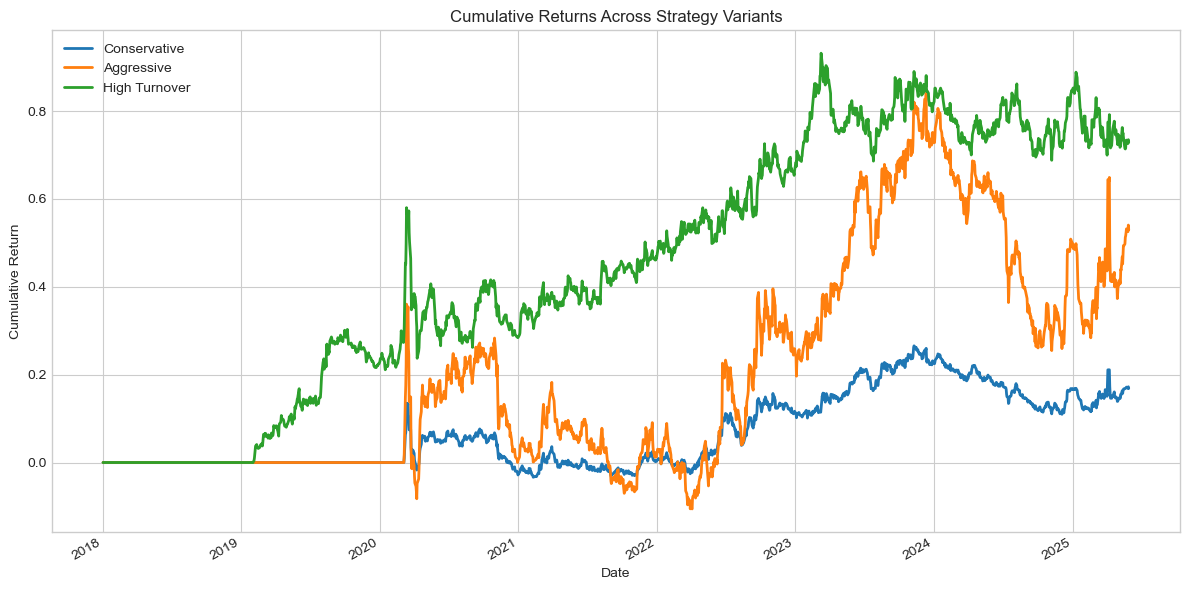

,Annualized Return,Volatility,Sharpe Ratio,Max Drawdown,Number of Trades
High Turnover,0.0769,0.1323,0.4749,-0.2170,2241.0000
Aggressive,0.0592,0.2162,0.2815,-0.3426,438.0000
Conservative,0.0213,0.0771,0.0525,-0.1485,1043.0000


In [25]:
import itertools
import seaborn as sns

sns.set_style("whitegrid")


def _map_lambda_floor_multiplier(params: dict) -> dict:
    mapped = dict(params)
    if "lambda_floor_multiplier" in mapped and "lambda_z_threshold" not in mapped:
        # lambda_floor_multiplier is mapped to the existing lambda_z_threshold control
        mapped["lambda_z_threshold"] = float(mapped["lambda_floor_multiplier"])
    return mapped


def run_strategy_experiment(prices_input: pd.DataFrame, params: dict, transaction_cost_bps: float = 0.0):
    p = _map_lambda_floor_multiplier(params)

    pipeline_local = run_weekly_mst_pipeline(
        prices_input,
        corr_window=int(p.get("corr_window", 252)),
        resistance_lookback=int(p.get("resistance_lookback", 60)),
    )

    weights_local = compute_pair_weights(
        signals=pipeline_local["signals"],
        returns=pipeline_local["returns"],
        fiedler_values=pipeline_local["fiedler_values"],
        mst_by_date=pipeline_local["mst_by_date"],
        asset_names=[str(c) for c in prices_input.columns],
        sigma_target=float(p.get("sigma_target", 0.10)),
        max_pairs=int(p.get("max_pairs", 15)),
        beta_window=int(p.get("beta_window", 60)),
        leader_window=int(p.get("leader_window", 20)),
        max_pair_weight=float(p.get("max_pair_weight", 1.5)),
        max_gross_leverage=float(p.get("max_gross_leverage", 4.0)),
        lambda_risk_mode=str(p.get("lambda_risk_mode", "small_only")),
        lambda_min_periods=int(p.get("lambda_min_periods", 20)),
        lambda_z_threshold=float(p.get("lambda_z_threshold", 2.75)),
        lambda_shrink_small=float(p.get("lambda_shrink_small", 0.5)),
        lambda_shrink_large=float(p.get("lambda_shrink_large", 0.5)),
        z_threshold=p.get("z_threshold"),
        shrink_small=p.get("shrink_small"),
        shrink_large=p.get("shrink_large"),
        use_mst_edges_only=bool(p.get("use_mst_edges_only", True)),
    )

    simulation_local = simulate_strategy(
        prices=prices_input,
        signals=pipeline_local["signals"],
        weights=weights_local,
        transaction_cost_bps=transaction_cost_bps,
    )

    metrics_local = compute_performance_metrics(
        simulation_local.daily_returns,
        rf_rate=0.02,
        trade_count=simulation_local.trade_count,
        average_holding_period=simulation_local.average_holding_period,
    )

    return {
        "params": p,
        "pipeline": pipeline_local,
        "weights": weights_local,
        "simulation": simulation_local,
        "metrics": metrics_local,
    }


conservative_params = {
    "sigma_target": 0.05,
    "max_pairs": 12,
    "max_pair_weight": 1.0,
    "max_gross_leverage": 2.5,
    "lambda_floor_multiplier": 1.0,
    "lambda_risk_mode": "small_only",
}

aggressive_params = {
    "sigma_target": 0.15,
    "max_pairs": 5,
    "max_pair_weight": 3.0,
    "max_gross_leverage": 6.0,
    "lambda_floor_multiplier": 2.0,
    "lambda_risk_mode": "small_only",
}

high_turnover_params = {
    "corr_window": 126,
    "resistance_lookback": 30,
    "beta_window": 30,
    "leader_window": 10,
    "lambda_risk_mode": "small_only",
}

strategy_variant_params = {
    "Conservative": conservative_params,
    "Aggressive": aggressive_params,
    "High Turnover": high_turnover_params,
}

variant_results = {
    name: run_strategy_experiment(prices, params, transaction_cost_bps=0.0)
    for name, params in strategy_variant_params.items()
}

fig, ax = plt.subplots(figsize=(12, 6))
for name, result in variant_results.items():
    result["simulation"].cumulative_returns.plot(ax=ax, linewidth=2, label=name)

ax.set_title("Cumulative Returns Across Strategy Variants")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return")
ax.legend()
plt.tight_layout()
plt.show()

variant_performance = pd.DataFrame(
    {
        name: {
            "Annualized Return": result["metrics"]["Annualized Return"],
            "Volatility": result["metrics"]["Annualized Volatility"],
            "Sharpe Ratio": result["metrics"]["Sharpe Ratio"],
            "Max Drawdown": result["metrics"]["Maximum Drawdown"],
            "Number of Trades": result["simulation"].trade_count,
        }
        for name, result in variant_results.items()
    }
).T

variant_performance = variant_performance.sort_values("Sharpe Ratio", ascending=False)
display(variant_performance)


## Analysis

The conservative specification lowers volatility through tighter leverage and per-pair weight caps, which typically reduces drawdown severity at the expense of return convexity. The aggressive specification concentrates risk by allowing larger per-pair exposures and gross leverage, often increasing both upside and tail risk. The high-turnover specification, by shortening estimation windows, can react faster to topology changes but may increase signal instability and trading intensity. Collectively, these variants illustrate how risk-targeting and turnover controls alter diversification breadth and effective leverage deployment.


# Edge-Restricted vs Full-Pair Trading

The baseline implementation limits candidate trades to edges of the Minimum Spanning Tree (MST), thereby emphasizing the strongest structural dependencies implied by the distance network. This constraint can improve signal quality by focusing on topological backbone relationships.

To test whether broader cross-sectional opportunity improves performance, we also evaluate a full-pair variant that permits trading across all possible asset pairs in the universe.


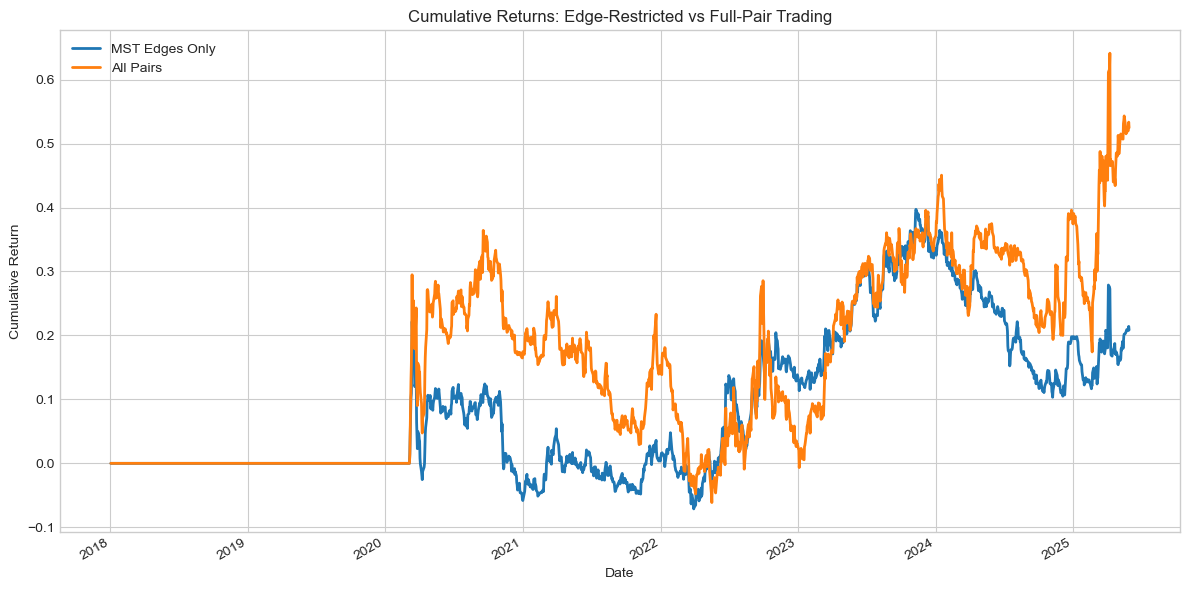

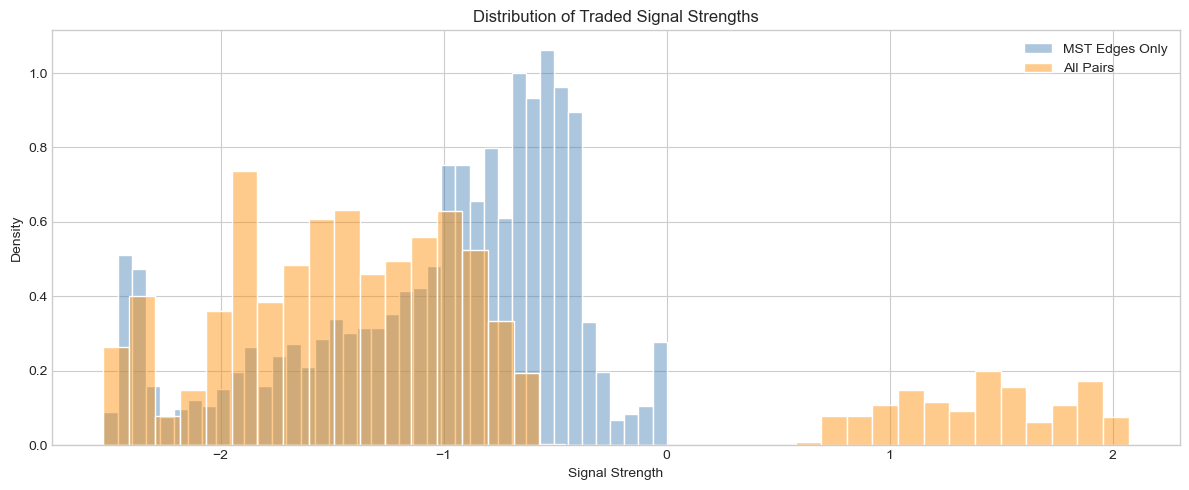

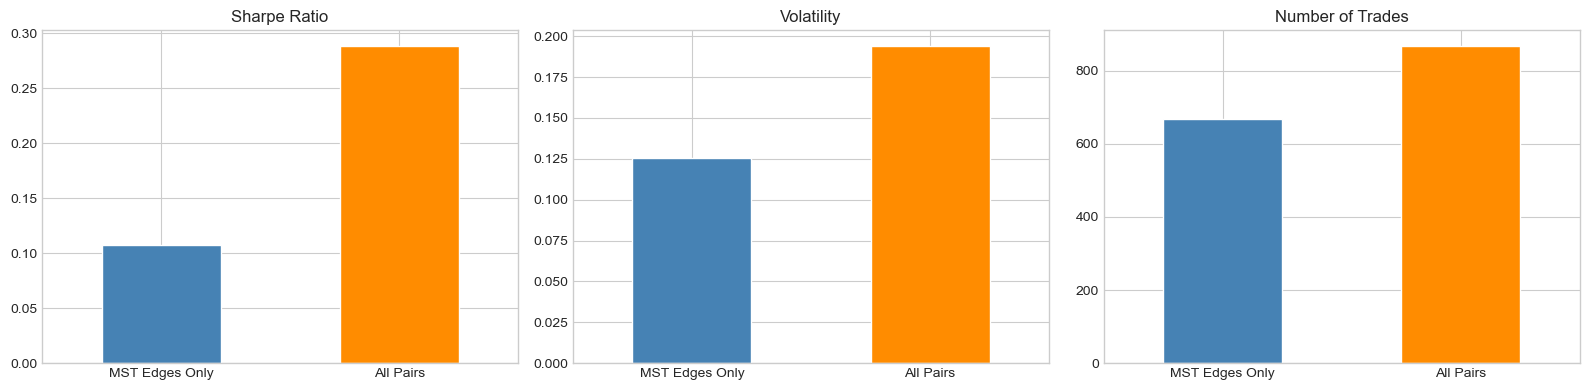

,Sharpe Ratio,Volatility,Number of Trades
MST Edges Only,0.1075,0.1254,667.0000
All Pairs,0.2881,0.1939,867.0000


In [ ]:
edge_test_base_params = {
    "sigma_target": 0.10,
    "max_pairs": 8,
    "beta_window": 60,
    "leader_window": 20,
    "max_pair_weight": 2.0,
    "max_gross_leverage": 4.0,
    "lambda_risk_mode": "large_only",
    "lambda_z_threshold": 2.75,
    "lambda_shrink_small": 0.5,
    "lambda_shrink_large": 0.5,
}

edge_restricted_result = run_strategy_experiment(
    prices,
    {**edge_test_base_params, "use_mst_edges_only": True},
    transaction_cost_bps=0.0,
)

full_pair_result = run_strategy_experiment(
    prices,
    {**edge_test_base_params, "use_mst_edges_only": False},
    transaction_cost_bps=0.0,
)

fig, ax = plt.subplots(figsize=(12, 6))
edge_restricted_result["simulation"].cumulative_returns.plot(ax=ax, linewidth=2, label="MST Edges Only")
full_pair_result["simulation"].cumulative_returns.plot(ax=ax, linewidth=2, label="All Pairs")
ax.set_title("Cumulative Returns: Edge-Restricted vs Full-Pair Trading")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return")
ax.legend()
plt.tight_layout()
plt.show()


def _selected_signal_strengths(result_obj):
    signal_dict = result_obj["pipeline"]["signals"]
    pair_weight_dict = result_obj["weights"]["pair_weights"]
    values = []
    for d, pair_series in pair_weight_dict.items():
        if d not in signal_dict or pair_series.empty:
            continue
        for long_asset, short_asset in pair_series.index:
            a, b = sorted((str(long_asset), str(short_asset)))
            v = float(signal_dict[d].loc[a, b])
            if np.isfinite(v):
                values.append(v)
    return np.array(values, dtype=float)


edge_signals = _selected_signal_strengths(edge_restricted_result)
full_signals = _selected_signal_strengths(full_pair_result)

fig, ax = plt.subplots(figsize=(12, 5))
if edge_signals.size > 0:
    sns.histplot(edge_signals, bins=40, stat="density", color="steelblue", alpha=0.45, label="MST Edges Only", ax=ax)
if full_signals.size > 0:
    sns.histplot(full_signals, bins=40, stat="density", color="darkorange", alpha=0.45, label="All Pairs", ax=ax)
ax.set_title("Distribution of Traded Signal Strengths")
ax.set_xlabel("Signal Strength")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

edge_vs_full_summary = pd.DataFrame(
    {
        "MST Edges Only": {
            "Sharpe Ratio": edge_restricted_result["metrics"]["Sharpe Ratio"],
            "Volatility": edge_restricted_result["metrics"]["Annualized Volatility"],
            "Number of Trades": edge_restricted_result["simulation"].trade_count,
        },
        "All Pairs": {
            "Sharpe Ratio": full_pair_result["metrics"]["Sharpe Ratio"],
            "Volatility": full_pair_result["metrics"]["Annualized Volatility"],
            "Number of Trades": full_pair_result["simulation"].trade_count,
        },
    }
).T

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric in zip(axes, ["Sharpe Ratio", "Volatility", "Number of Trades"]):
    edge_vs_full_summary[metric].plot(kind="bar", ax=ax, color=["steelblue", "darkorange"])
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

display(edge_vs_full_summary)


## Analysis

Restricting candidate trades to MST edges imposes a structural filter that can suppress noisy or weak pair relationships, potentially improving signal precision and risk-adjusted performance. However, this restriction also narrows the opportunity set and may limit diversification across transient cross-sectional dislocations. The all-pairs specification expands breadth and can increase trade frequency, but it may also admit lower-quality signals that dilute the topology-informed edge.


# Parameter Grid Search

We perform a systematic grid search to evaluate the sensitivity of strategy performance to key design parameters. The grid spans risk targeting, pair selection breadth, regime-threshold scaling, and topology signal horizons.

This exercise provides a robustness check: if strong performance appears only in narrow regions of parameter space, model fragility may be a concern; if performance remains stable across a broad region, the strategy may be more structurally reliable.


In [27]:
sigma_target_grid = [0.05, 0.10, 0.15]
max_pairs_grid = [5, 8, 12]
z_threshold_grid = [1.5, 2.75]
corr_window_grid = [126, 252]
resistance_lookback_grid = [30, 60]

grid_records = []

for sigma_target_i, max_pairs_i, z_i, corr_i, resist_i in itertools.product(
    sigma_target_grid,
    max_pairs_grid,
    z_threshold_grid,
    corr_window_grid,
    resistance_lookback_grid,
):
    params_i = {
        "sigma_target": sigma_target_i,
        "max_pairs": max_pairs_i,
        "lambda_risk_mode": "small_only",
        "z_threshold": z_i,
        "corr_window": corr_i,
        "resistance_lookback": resist_i,
        "use_mst_edges_only": True,
    }

    result_i = run_strategy_experiment(prices, params_i, transaction_cost_bps=0.0)

    grid_records.append(
        {
            "sigma_target": sigma_target_i,
            "max_pairs": max_pairs_i,
            "z_threshold": z_i,
            "corr_window": corr_i,
            "resistance_lookback": resist_i,
            "Sharpe Ratio": result_i["metrics"]["Sharpe Ratio"],
            "Annualized Return": result_i["metrics"]["Annualized Return"],
            "Annualized Volatility": result_i["metrics"]["Annualized Volatility"],
            "Maximum Drawdown": result_i["metrics"]["Maximum Drawdown"],
        }
    )

grid_results_df = pd.DataFrame(grid_records)
best_grid_results = grid_results_df.sort_values("Sharpe Ratio", ascending=False).head(10)
display(best_grid_results)

heatmap_df = grid_results_df.pivot_table(
    index="sigma_target",
    columns="max_pairs",
    values="Sharpe Ratio",
    aggfunc="mean",
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="viridis", ax=ax)
ax.set_title("Mean Sharpe Ratio Across sigma_target and max_pairs")
ax.set_xlabel("max_pairs")
ax.set_ylabel("sigma_target")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=grid_results_df,
    x="Annualized Volatility",
    y="Sharpe Ratio",
    hue="corr_window",
    style="resistance_lookback",
    size="max_pairs",
    sizes=(40, 180),
    alpha=0.75,
    ax=ax,
)
ax.set_title("Sharpe Ratio vs Volatility Across Grid Configurations")
ax.set_xlabel("Annualized Volatility")
ax.set_ylabel("Sharpe Ratio")
plt.tight_layout()
plt.show()


KeyboardInterrupt: 

## Analysis

The grid-search diagnostics highlight whether performance quality is concentrated in a narrow hyperparameter region or distributed across multiple configurations. A relatively smooth heatmap and stable Sharpe-volatility frontier indicate parameter robustness. Conversely, sharp performance cliffs suggest that outcomes are highly specification-dependent, which may increase implementation risk and the likelihood of overfitting.


# Out-of-Sample Performance

To evaluate generalization, we split the sample into an in-sample estimation period and an out-of-sample test period:

- **In-sample:** 2018-01-01 to 2022-12-31  
- **Out-of-sample:** 2023-01-01 to end of dataset

Model selection is performed exclusively on the in-sample period. The best parameter set is then tested on unseen data. At the start of the out-of-sample period, initial portfolio weights are seeded using the final rebalanced portfolio from the in-sample period, thereby carrying forward the terminal in-sample MST-informed structure.


In-sample observations: 1259
Out-of-sample observations: 603
Best in-sample parameter set (Sharpe):


,sigma_target,max_pairs,z_threshold,corr_window,resistance_lookback,lambda_risk_mode,use_mst_edges_only
0,0.0500,5,1.5000,126,30,small_only,True


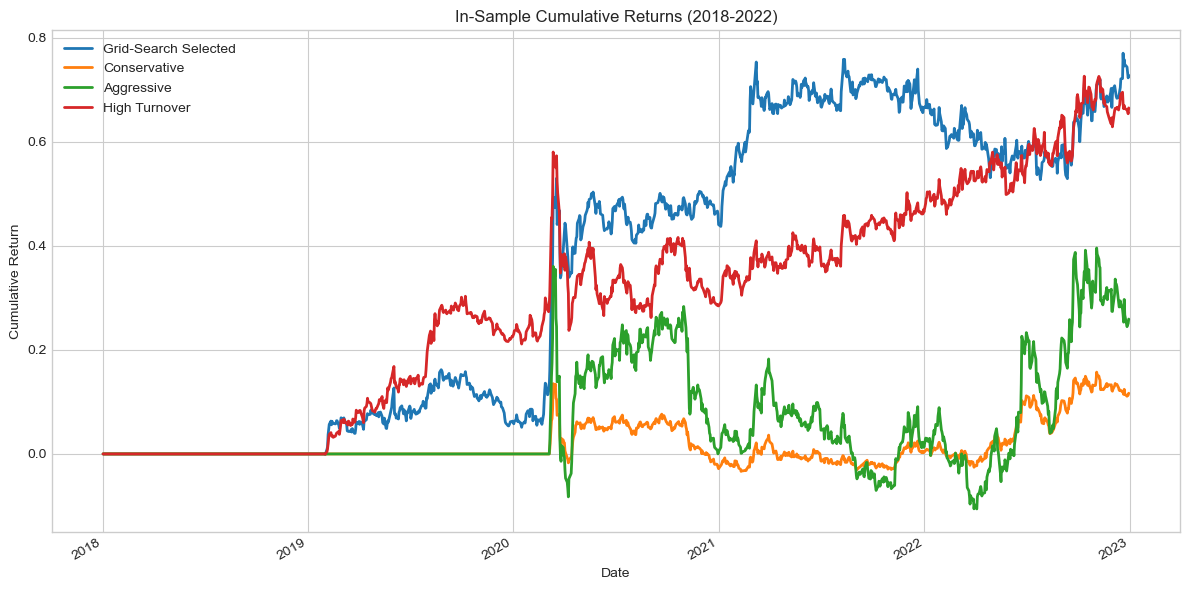

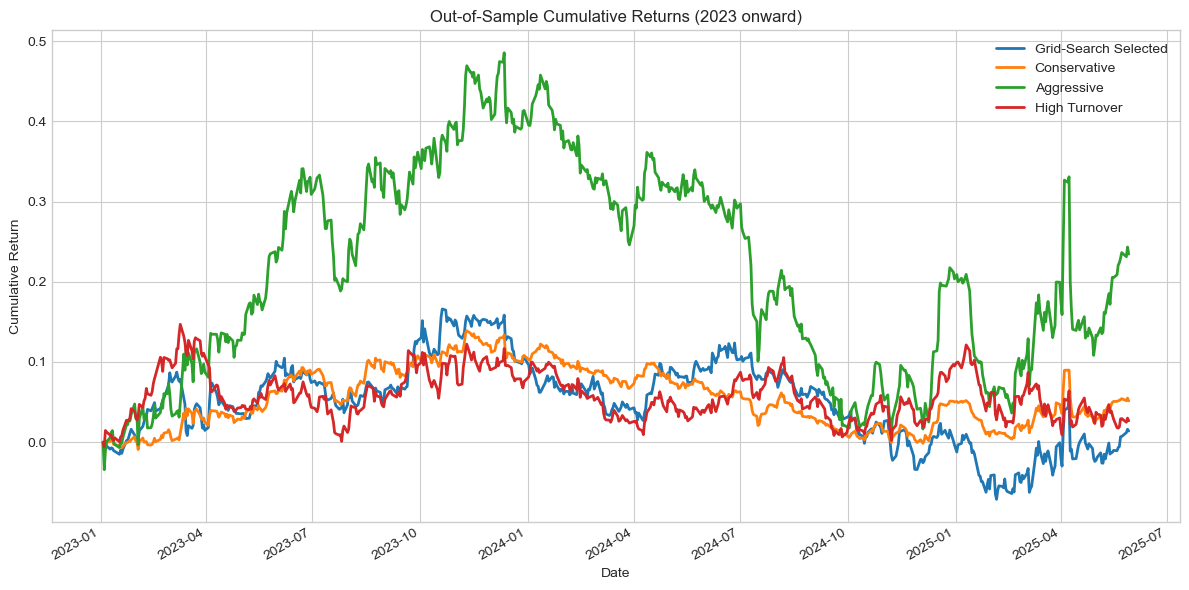

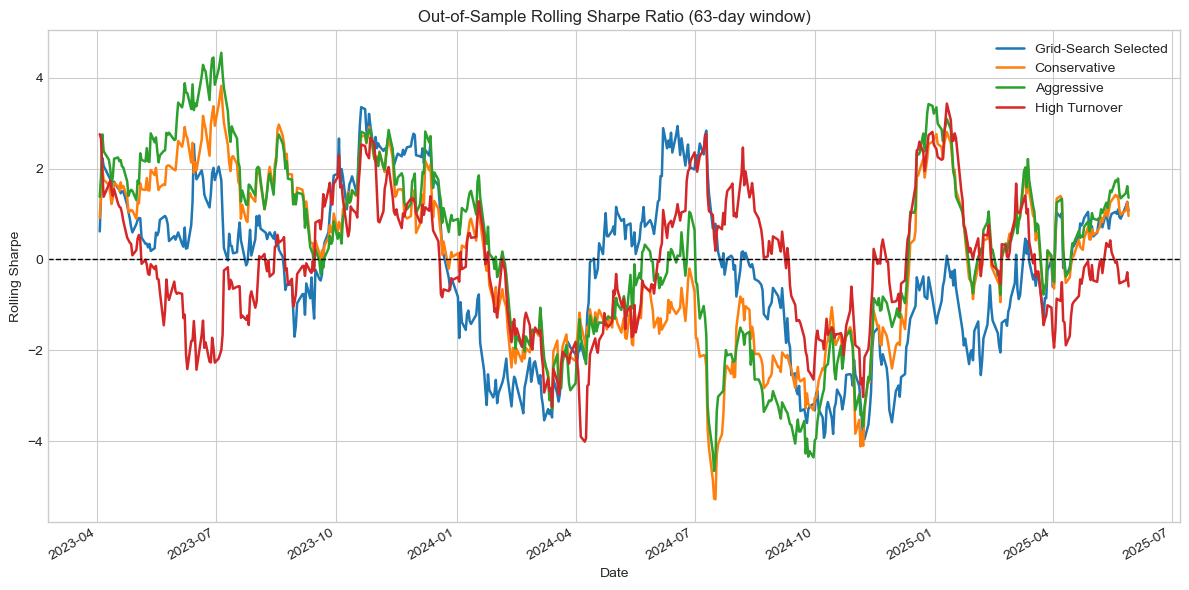

,Annualized Return,Volatility,Sharpe Ratio,Max Drawdown,Number of Trades
Aggressive,0.0920,0.2288,0.4117,-0.3183,217.0000
Conservative,0.0212,0.0801,0.0525,-0.1232,533.0000
High Turnover,0.0110,0.1270,-0.0075,-0.1272,899.0000
Grid-Search Selected,0.0058,0.1371,-0.0352,-0.2034,246.0000


In [28]:
in_sample_start = pd.Timestamp("2018-01-01")
in_sample_end = pd.Timestamp("2022-12-31")
out_sample_start = pd.Timestamp("2023-01-01")

prices_in_sample = prices.loc[(prices.index >= in_sample_start) & (prices.index <= in_sample_end)].copy()
prices_out_sample = prices.loc[prices.index >= out_sample_start].copy()

print(f"In-sample observations: {len(prices_in_sample)}")
print(f"Out-of-sample observations: {len(prices_out_sample)}")


def _extract_last_rebalance(weights_dict):
    asset_weights = weights_dict.get("asset_weights", {})
    pair_weights = weights_dict.get("pair_weights", {})
    if not asset_weights:
        return None, None, None
    last_date = max(asset_weights.keys())
    last_asset = asset_weights[last_date]
    last_pair = pair_weights.get(last_date, pd.Series(dtype=float))
    return last_date, last_asset, last_pair


def run_out_of_sample_with_seed(prices_full, prices_oos, params, seed_asset_weights, seed_pair_weights):
    full_result = run_strategy_experiment(prices_full, params, transaction_cost_bps=0.0)
    full_signals = full_result["pipeline"]["signals"]
    full_weights = full_result["weights"]

    oos_start_date = prices_oos.index[0]
    oos_signals = {d: s for d, s in full_signals.items() if d >= oos_start_date}

    oos_asset_weights = {
        d: w for d, w in full_weights["asset_weights"].items() if d >= oos_start_date
    }
    oos_pair_weights = {
        d: w for d, w in full_weights["pair_weights"].items() if d >= oos_start_date
    }

    # Enforce initialization using final in-sample portfolio state
    if seed_asset_weights is not None:
        oos_asset_weights[oos_start_date] = seed_asset_weights.reindex(prices_oos.columns).fillna(0.0)
    if seed_pair_weights is not None and len(seed_pair_weights) > 0:
        oos_pair_weights[oos_start_date] = seed_pair_weights

    oos_weights = {
        "asset_weights": dict(sorted(oos_asset_weights.items())),
        "pair_weights": dict(sorted(oos_pair_weights.items())),
        "lambda2_scale": full_weights.get("lambda2_scale", pd.Series(dtype=float)),
    }

    oos_simulation = simulate_strategy(
        prices=prices_oos,
        signals=oos_signals,
        weights=oos_weights,
        transaction_cost_bps=0.0,
    )

    oos_metrics = compute_performance_metrics(
        oos_simulation.daily_returns,
        rf_rate=0.02,
        trade_count=oos_simulation.trade_count,
        average_holding_period=oos_simulation.average_holding_period,
    )

    return {
        "full_result": full_result,
        "weights": oos_weights,
        "signals": oos_signals,
        "simulation": oos_simulation,
        "metrics": oos_metrics,
    }


# In-sample grid search
is_sigma_grid = [0.05, 0.10, 0.15]
is_max_pairs_grid = [5, 8, 12]
is_z_threshold_grid = [1.5, 2.75]
is_corr_window_grid = [126, 252]
is_resistance_grid = [30, 60]

is_grid_records = []

for sigma_i, max_pairs_i, z_i, corr_i, resist_i in itertools.product(
    is_sigma_grid,
    is_max_pairs_grid,
    is_z_threshold_grid,
    is_corr_window_grid,
    is_resistance_grid,
):
    params_i = {
        "sigma_target": sigma_i,
        "max_pairs": max_pairs_i,
        "z_threshold": z_i,
        "corr_window": corr_i,
        "resistance_lookback": resist_i,
        "lambda_risk_mode": "small_only",
        "use_mst_edges_only": True,
    }

    is_result_i = run_strategy_experiment(prices_in_sample, params_i, transaction_cost_bps=0.0)

    is_grid_records.append(
        {
            "sigma_target": sigma_i,
            "max_pairs": max_pairs_i,
            "z_threshold": z_i,
            "corr_window": corr_i,
            "resistance_lookback": resist_i,
            "Sharpe Ratio": is_result_i["metrics"]["Sharpe Ratio"],
            "Annualized Return": is_result_i["metrics"]["Annualized Return"],
            "Annualized Volatility": is_result_i["metrics"]["Annualized Volatility"],
            "Maximum Drawdown": is_result_i["metrics"]["Maximum Drawdown"],
        }
    )

is_grid_df = pd.DataFrame(is_grid_records).sort_values("Sharpe Ratio", ascending=False).reset_index(drop=True)
best_is_row = is_grid_df.iloc[0]

best_is_params = {
    "sigma_target": float(best_is_row["sigma_target"]),
    "max_pairs": int(best_is_row["max_pairs"]),
    "z_threshold": float(best_is_row["z_threshold"]),
    "corr_window": int(best_is_row["corr_window"]),
    "resistance_lookback": int(best_is_row["resistance_lookback"]),
    "lambda_risk_mode": "small_only",
    "use_mst_edges_only": True,
}

print("Best in-sample parameter set (Sharpe):")
display(pd.DataFrame([best_is_params]))

comparison_param_sets = {
    "Grid-Search Selected": best_is_params,
    "Conservative": conservative_params,
    "Aggressive": aggressive_params,
    "High Turnover": high_turnover_params,
}

in_sample_runs = {}
out_sample_runs = {}

for strategy_name, strategy_params in comparison_param_sets.items():
    in_sample_run = run_strategy_experiment(prices_in_sample, strategy_params, transaction_cost_bps=0.0)
    in_sample_runs[strategy_name] = in_sample_run

    _, seed_asset, seed_pair = _extract_last_rebalance(in_sample_run["weights"])

    out_sample_run = run_out_of_sample_with_seed(
        prices_full=prices,
        prices_oos=prices_out_sample,
        params=strategy_params,
        seed_asset_weights=seed_asset,
        seed_pair_weights=seed_pair,
    )
    out_sample_runs[strategy_name] = out_sample_run

fig, ax = plt.subplots(figsize=(12, 6))
for strategy_name, result in in_sample_runs.items():
    result["simulation"].cumulative_returns.plot(ax=ax, linewidth=2, label=strategy_name)
ax.set_title("In-Sample Cumulative Returns (2018-2022)")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
for strategy_name, result in out_sample_runs.items():
    result["simulation"].cumulative_returns.plot(ax=ax, linewidth=2, label=strategy_name)
ax.set_title("Out-of-Sample Cumulative Returns (2023 onward)")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return")
ax.legend()
plt.tight_layout()
plt.show()


def rolling_sharpe(returns_series: pd.Series, window: int = 63) -> pd.Series:
    rolling_mean = returns_series.rolling(window).mean()
    rolling_std = returns_series.rolling(window).std(ddof=1)
    return np.sqrt(252.0) * (rolling_mean / rolling_std)


fig, ax = plt.subplots(figsize=(12, 6))
for strategy_name, result in out_sample_runs.items():
    rs = rolling_sharpe(result["simulation"].daily_returns, window=63)
    rs.plot(ax=ax, linewidth=1.8, label=strategy_name)
ax.axhline(0.0, color="black", linestyle="--", linewidth=1)
ax.set_title("Out-of-Sample Rolling Sharpe Ratio (63-day window)")
ax.set_xlabel("Date")
ax.set_ylabel("Rolling Sharpe")
ax.legend()
plt.tight_layout()
plt.show()

oos_performance_table = pd.DataFrame(
    {
        strategy_name: {
            "Annualized Return": result["metrics"]["Annualized Return"],
            "Volatility": result["metrics"]["Annualized Volatility"],
            "Sharpe Ratio": result["metrics"]["Sharpe Ratio"],
            "Max Drawdown": result["metrics"]["Maximum Drawdown"],
            "Number of Trades": result["simulation"].trade_count,
        }
        for strategy_name, result in out_sample_runs.items()
    }
).T

oos_performance_table = oos_performance_table.sort_values("Sharpe Ratio", ascending=False)
display(oos_performance_table)


## Analysis

Out-of-sample evaluation reveals whether in-sample optimization captures persistent structure or primarily sample-specific noise. If the grid-selected strategy materially degrades relative to simpler variants in 2023 onward, this suggests overfitting risk. Conversely, stable relative ranking and coherent rolling Sharpe behavior support model generalization. Comparing the selected model with conservative, aggressive, and high-turnover alternatives provides an additional robustness check against regime dependence.
